# CSC4093 / DSC4213 — Programming Assignment 01
## Personal Health Mention (PHM) Tweet Classification using LSTM and Bi-LSTM

## 1. Install & Import Libraries

In [25]:
# Install required libraries
#%pip install nltk tensorflow scikit-learn matplotlib seaborn scipy --quiet

In [26]:
# ── Core imports ───────────────────────────────────────────────────────────────
import os
import random
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, precision_recall_curve
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Bidirectional,
    Dense, Dropout, SpatialDropout1D
)
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)




## 2. Load Dataset

In [27]:
# ── Load data ──────────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
train_path = '/content/drive/My Drive/PHM/phm_train.csv'
test_path  = '/content/drive/My Drive/PHM/phm_test.csv'

train_data = pd.read_csv(train_path)
test_data  = pd.read_csv(test_path)

print('Train shape:', train_data.shape)
print('Test  shape:', test_data.shape)
print()
print('Train label distribution:')
print(train_data['label'].value_counts())
print()
print('Test label distribution:')
print(test_data['label'].value_counts())
print()
train_data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train shape: (9991, 3)
Test  shape: (3331, 3)

Train label distribution:
label
0    7091
1    2900
Name: count, dtype: int64

Test label distribution:
label
0    2364
1     967
Name: count, dtype: int64



,tweet_id,label,tweet
0,6.430000e+17,0,user_mention all i can tell you is i have had ...
1,6.440000e+17,0,my doctor told me stop he gave me sum pop i mi...
2,8.150000e+17,1,i take tylenol and i wake up in the middle of ...
3,6.820000e+17,0,i got xans in an advil bottle i dont take them...
4,6.440000e+17,1,mom says i need to stop eating so much bc ive ...


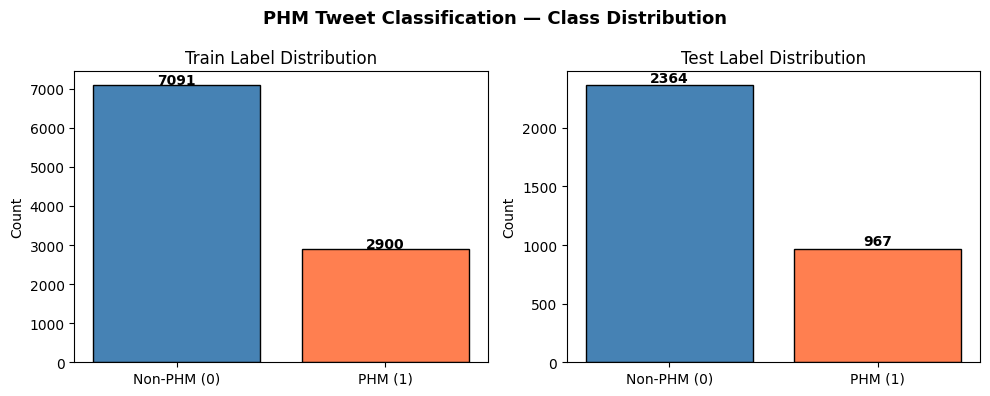

Class imbalance ratio (Non-PHM:PHM): 2.45x


In [28]:
# ── Visualise class distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, df, title in zip(axes, [train_data, test_data], ['Train', 'Test']):
    counts = df['label'].value_counts()
    ax.bar(['Non-PHM (0)', 'PHM (1)'], [counts[0], counts[1]],
           color=['steelblue', 'coral'], edgecolor='black')
    ax.set_title(f'{title} Label Distribution')
    ax.set_ylabel('Count')
    for i, v in enumerate([counts[0], counts[1]]):
        ax.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.suptitle('PHM Tweet Classification — Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = train_data['label'].value_counts()[0] / train_data['label'].value_counts()[1]
print(f'Class imbalance ratio (Non-PHM:PHM): {ratio:.2f}x')

## 3. Text Preprocessing

In [29]:
# ── Custom stopword list ───────────────────────────────────────────────────────
nltk.download('stopwords', quiet=True)
english_stops = set(stopwords.words('english'))

keep_words = {
    # Personal pronouns — essential for distinguishing personal vs general mentions
    'i', 'me', 'my', 'myself',
    'we', 'our', 'ours', 'ourselves',
    'you', 'your', 'yours', 'yourself', 'yourselves',
    'he', 'him', 'his', 'himself',
    'she', 'her', 'hers', 'herself',
    'they', 'them', 'their', 'theirs', 'themselves',
    # Negations — important for sentiment/health context
    'not', 'no', 'nor', 'never', 'none',
    # Degree / intensity
    'very', 'too', 'more', 'most', 'so', 'such', 'just', 'now',
    # Temporal (relevant for symptom duration)
    'still', 'again', 'already',
}

custom_stops = english_stops - keep_words

print(f'Original stopwords : {len(english_stops)}')
print(f'Custom stopwords   : {len(custom_stops)}')
print(f'Words kept         : {sorted(keep_words & english_stops)}')

Original stopwords : 198
Custom stopwords   : 160
Words kept         : ['again', 'he', 'her', 'hers', 'herself', 'him', 'himself', 'his', 'i', 'just', 'me', 'more', 'most', 'my', 'myself', 'no', 'nor', 'not', 'now', 'our', 'ours', 'ourselves', 'she', 'so', 'such', 'their', 'theirs', 'them', 'themselves', 'they', 'too', 'very', 'we', 'you', 'your', 'yours', 'yourself', 'yourselves']


In [30]:
def preprocess_tweet(text):
    """Clean a single tweet for PHM classification."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'@\w+', '', text)                  # remove @mentions
    text = re.sub(r'#(\w+)', r'\1', text)             # keep hashtag words
    text = re.sub(r'\buser_mention\b', '', text)      # remove leftover placeholder
    text = re.sub(r'[^a-z\s]', ' ', text)             # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()          # normalise whitespace
    tokens = [w for w in text.split() if w not in custom_stops]
    return ' '.join(tokens)


def preprocess_dataset(train_df, test_df):
    """Apply preprocessing and return cleaned text + label arrays."""
    x_train = train_df['tweet'].apply(preprocess_tweet)
    x_test  = test_df['tweet'].apply(preprocess_tweet)
    y_train = train_df['label'].values.astype(int)
    y_test  = test_df['label'].values.astype(int)
    return x_train, x_test, y_train, y_test


x_train_text, x_test_text, y_train, y_test = preprocess_dataset(train_data, test_data)

print('Sample cleaned tweets:')
for i in range(3):
    print(f'  Original : {train_data["tweet"].iloc[i]}')
    print(f'  Cleaned  : {x_train_text.iloc[i]}')
    print(f'  Label    : {y_train[i]}')
    print()
print(f'Train samples: {len(x_train_text)} | Test samples: {len(x_test_text)}')

Sample cleaned tweets:
  Original : user_mention all i can tell you is i have had few relapses on it it is not a cure i hear if you dont test for the jc virus tysabri is good
  Cleaned  : i tell you i relapses not cure i hear you dont test jc virus tysabri good
  Label    : 0

  Original : my doctor told me stop he gave me sum pop i mix it up w some adderall and wait to get to the top i mix it up w some alcohol pour
  Cleaned  : my doctor told me stop he gave me sum pop i mix w adderall wait get top i mix w alcohol pour
  Label    : 0

  Original : i take tylenol and i wake up in the middle of the night to put my ice pack on my belly and back for a couple of seconds so i can sleep
  Cleaned  : i take tylenol i wake middle night put my ice pack my belly back couple seconds so i sleep
  Label    : 1

Train samples: 9991 | Test samples: 3331


## 3.5 Text Length Analysis

Token length statistics:
count    9991.000000
mean       10.742268
std         4.366257
min         1.000000
25%         7.000000
50%        11.000000
75%        14.000000
max        27.000000
Name: tweet, dtype: float64

95th percentile : 18 tokens
99th percentile : 21 tokens


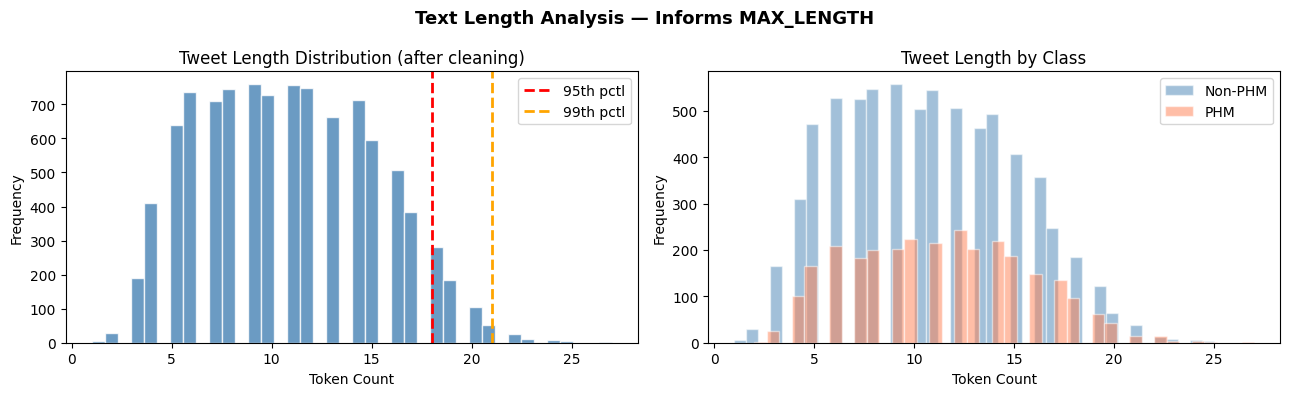

In [31]:
# ── Analyse tweet lengths to choose MAX_LENGTH ─────────────────────────────────
train_lengths = x_train_text.apply(lambda x: len(x.split()))

print('Token length statistics:')
print(train_lengths.describe())
print(f'\n95th percentile : {train_lengths.quantile(0.95):.0f} tokens')
print(f'99th percentile : {train_lengths.quantile(0.99):.0f} tokens')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(train_lengths, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(train_lengths.quantile(0.95), color='red', ls='--', lw=2, label='95th pctl')
axes[0].axvline(train_lengths.quantile(0.99), color='orange', ls='--', lw=2, label='99th pctl')
axes[0].set_xlabel('Token Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Tweet Length Distribution (after cleaning)')
axes[0].legend()

for label, color, name in [(0, 'steelblue', 'Non-PHM'), (1, 'coral', 'PHM')]:
    mask = y_train == label
    axes[1].hist(train_lengths[mask], bins=40, alpha=0.5, color=color, label=name, edgecolor='white')
axes[1].set_xlabel('Token Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Tweet Length by Class')
axes[1].legend()

plt.suptitle('Text Length Analysis — Informs MAX_LENGTH', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('text_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Tokenisation & Padding


In [32]:
# ── Hyperparameters ────────────────────────────────────────────────────────────
VOCAB_SIZE  = 10_000
MAX_LENGTH  = 30
EMBED_DIM   = 64
LSTM_UNITS  = 64
BATCH_SIZE  = 64
EPOCHS      = 20

# ── Tokeniser ─────────────────────────────────────────────────────────────────
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(x_train_text)   # fit on TRAINING data only

x_train_seq = tokenizer.texts_to_sequences(x_train_text)
x_test_seq  = tokenizer.texts_to_sequences(x_test_text)

x_train_pad = pad_sequences(x_train_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
x_test_pad  = pad_sequences(x_test_seq,  maxlen=MAX_LENGTH, padding='post', truncating='post')

VOCAB_SIZE_ACTUAL = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)

print(f'Vocabulary size  : {VOCAB_SIZE_ACTUAL}')
print(f'Max sequence len : {MAX_LENGTH}')
print(f'x_train_pad shape: {x_train_pad.shape}')
print(f'x_test_pad shape : {x_test_pad.shape}')

Vocabulary size  : 10000
Max sequence len : 30
x_train_pad shape: (9991, 30)
x_test_pad shape : (3331, 30)


In [33]:
# ── Handle class imbalance with class weights ──────────────────────────────────
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes.tolist(), weights.tolist()))
print('Class weights:', class_weight_dict)
print(f'  → Non-PHM weight: {class_weight_dict[0]:.3f}  (majority — penalised less)')
print(f'  → PHM weight    : {class_weight_dict[1]:.3f}  (minority — penalised MORE)')

Class weights: {0: 0.7044845578902834, 1: 1.7225862068965516}
  → Non-PHM weight: 0.704  (majority — penalised less)
  → PHM weight    : 1.723  (minority — penalised MORE)


## 5. Model Definitions

In [34]:
def build_lstm():
    """LSTM model for PHM classification."""
    model = Sequential(name='LSTM_Model')
    model.add(Input(shape=(MAX_LENGTH,)))
    model.add(Embedding(VOCAB_SIZE_ACTUAL, EMBED_DIM))
    model.add(SpatialDropout1D(0.3))
    model.add(LSTM(LSTM_UNITS, dropout=0.3, recurrent_dropout=0.3))
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(1e-4)))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_bilstm():
    """Bi-LSTM model for PHM classification."""
    model = Sequential(name='BiLSTM_Model')
    model.add(Input(shape=(MAX_LENGTH,)))
    model.add(Embedding(VOCAB_SIZE_ACTUAL, EMBED_DIM))
    model.add(SpatialDropout1D(0.3))
    model.add(Bidirectional(LSTM(LSTM_UNITS, dropout=0.3, recurrent_dropout=0.3)))
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(1e-4)))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


# ── Inspect model summaries ────────────────────────────────────────────────────
lstm_model = build_lstm()
print('=' * 55)
print('LSTM Model Summary')
print('=' * 55)
lstm_model.summary()

bilstm_model = build_bilstm()
print('\n' + '=' * 55)
print('Bi-LSTM Model Summary')
print('=' * 55)
bilstm_model.summary()

LSTM Model Summary


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 30, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 30, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,137 (2.58 MB)

 Trainable params: 675,137 (2.58 MB)

...

Model: "BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 30, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 30, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 710,209 (2.71 MB)

 Trainable params: 710,209 (2.71 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Train LSTM

In [35]:
os.makedirs('models', exist_ok=True)

lstm_callbacks = [
    ModelCheckpoint(
        'models/LSTM_PHM_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        mode='min',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print('Training LSTM model...')
lstm_history = lstm_model.fit(
    x_train_pad, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=lstm_callbacks,
    verbose=1
)

Training LSTM model...
Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.3749 - loss: 0.6985
Epoch 1: val_accuracy improved from -inf to 0.82000, saving model to models/LSTM_PHM_best.keras
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.3756 - loss: 0.6983 - val_accuracy: 0.8200 - val_loss: 0.4643 - learning_rate: 0.0010
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7656 - loss: 0.5438
Epoch 2: val_accuracy did not improve from 0.82000
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.7658 - loss: 0.5436 - val_accuracy: 0.7440 - val_loss: 0.5898 - learning_rate: 0.0010
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8341 - loss: 0.4373
Epoch 3: val_accuracy improved from 0.82000 to 0.86000, saving model to models/LSTM_PHM_best.keras
141/141 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.8341 - loss: 0.4372 - val_accuracy: 0.8600 - val_loss: 0.3535 - learning_rate: 0.0010
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 

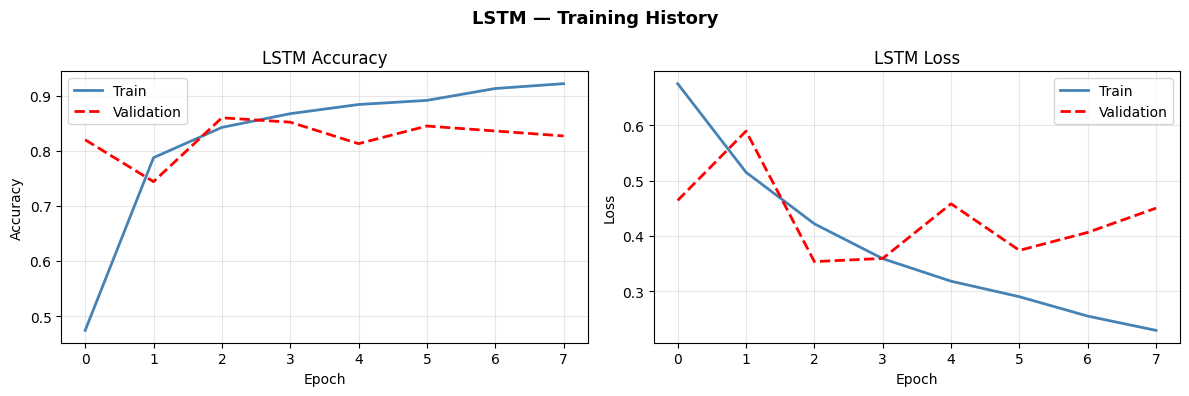

In [36]:
# ── Plot LSTM training curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('LSTM — Training History', fontsize=13, fontweight='bold')
for ax, metric, ylabel in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
    ax.plot(lstm_history.history[metric],          label='Train',      color='steelblue', lw=2)
    ax.plot(lstm_history.history[f'val_{metric}'], label='Validation', color='red', lw=2, linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(f'LSTM {ylabel}')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Train Bi-LSTM

In [37]:
bilstm_callbacks = [
    ModelCheckpoint(
        'models/BiLSTM_PHM_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        mode='min',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print('Training Bi-LSTM model...')
bilstm_history = bilstm_model.fit(
    x_train_pad, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=bilstm_callbacks,
    verbose=1
)

Training Bi-LSTM model...
Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.5490 - loss: 0.6657
Epoch 1: val_accuracy improved from -inf to 0.85000, saving model to models/BiLSTM_PHM_best.keras
141/141 ━━━━━━━━━━━━━━━━━━━━ 23s 106ms/step - accuracy: 0.5497 - loss: 0.6652 - val_accuracy: 0.8500 - val_loss: 0.4011 - learning_rate: 0.0010
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.8270 - loss: 0.4279
Epoch 2: val_accuracy improved from 0.85000 to 0.86300, saving model to models/BiLSTM_PHM_best.keras
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - accuracy: 0.8270 - loss: 0.4277 - val_accuracy: 0.8630 - val_loss: 0.3701 - learning_rate: 0.0010
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.8580 - loss: 0.3544
Epoch 3: val_accuracy did not improve from 0.86300
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 100ms/step - accuracy: 0.8580 - loss: 0.3543 - val_accuracy: 0.8390 - val_loss: 0.4037 - learning_rate: 0.0010
Epoch 4/20
141/141 ━━━━━━━━━━━━

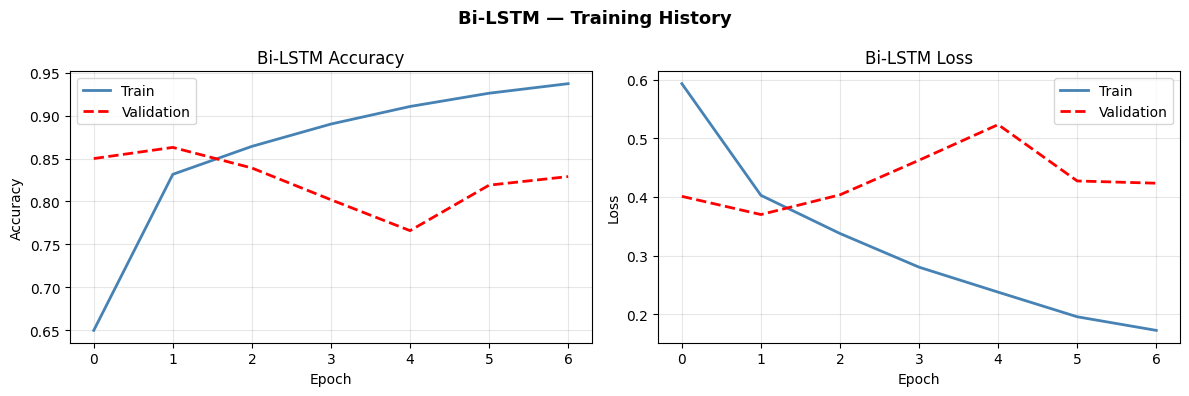

In [38]:
# ── Plot Bi-LSTM training curves ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Bi-LSTM — Training History', fontsize=13, fontweight='bold')
for ax, metric, ylabel in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
    ax.plot(bilstm_history.history[metric],          label='Train',      color='steelblue', lw=2)
    ax.plot(bilstm_history.history[f'val_{metric}'], label='Validation', color='red', lw=2, linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Bi-LSTM {ylabel}')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('bilstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Optimal Threshold Selection

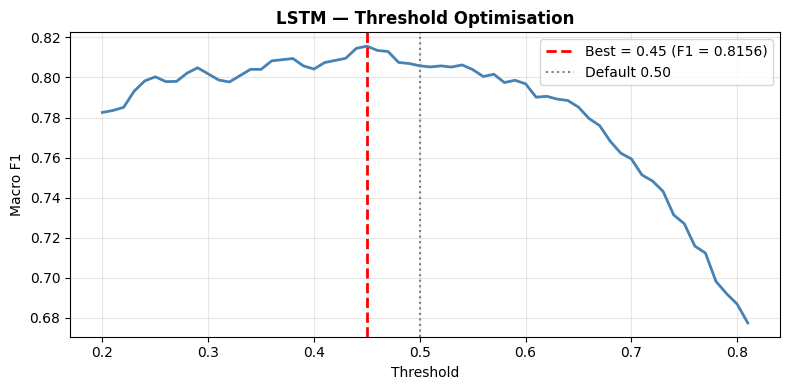

LSTM optimal threshold: 0.45  →  Macro F1 = 0.8156


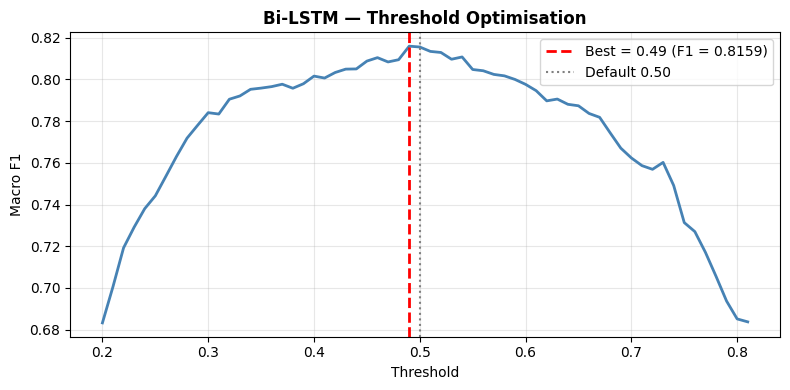

Bi-LSTM optimal threshold: 0.49  →  Macro F1 = 0.8159


In [39]:
def find_optimal_threshold(model, X_val, y_val, name):
    """Sweep thresholds and find the one maximising macro-F1."""
    y_prob = model.predict(X_val, verbose=0).flatten()
    thresholds = np.arange(0.20, 0.81, 0.01)
    f1_scores = []
    for t in thresholds:
        preds = (y_prob >= t).astype(int)
        f1_scores.append(f1_score(y_val, preds, average='macro'))

    best_idx = np.argmax(f1_scores)
    best_t   = thresholds[best_idx]
    best_f1  = f1_scores[best_idx]

    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, f1_scores, color='steelblue', lw=2)
    plt.axvline(best_t, color='red', ls='--', lw=2, label=f'Best = {best_t:.2f} (F1 = {best_f1:.4f})')
    plt.axvline(0.5, color='gray', ls=':', lw=1.5, label='Default 0.50')
    plt.xlabel('Threshold')
    plt.ylabel('Macro F1')
    plt.title(f'{name} — Threshold Optimisation', fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{name.lower().replace("-","")}_threshold_sweep.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'{name} optimal threshold: {best_t:.2f}  →  Macro F1 = {best_f1:.4f}')
    return best_t

# Use validation split (last 10%) for threshold selection
val_size = int(0.1 * len(x_train_pad))
X_val_thresh = x_train_pad[-val_size:]
y_val_thresh = y_train[-val_size:]

lstm_threshold   = find_optimal_threshold(lstm_model,   X_val_thresh, y_val_thresh, 'LSTM')
bilstm_threshold = find_optimal_threshold(bilstm_model, X_val_thresh, y_val_thresh, 'Bi-LSTM')

## 9. Evaluation on Test Set

In [40]:
def evaluate_model(model, X_test, y_test, name, threshold=0.5):
    """Full evaluation: accuracy, F1, AUC, classification report."""
    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= threshold).astype(int)

    acc    = accuracy_score(y_test, y_pred)
    prec   = precision_score(y_test, y_pred, zero_division=0)
    rec    = recall_score(y_test, y_pred, zero_division=0)
    f1_w   = f1_score(y_test, y_pred, average='weighted')
    f1_mac = f1_score(y_test, y_pred, average='macro')
    auc    = roc_auc_score(y_test, y_prob)

    print(f'\n{"="*55}')
    print(f'  {name} — Test Results  (threshold={threshold:.2f})')
    print(f'{"="*55}')
    print(f'  Accuracy      : {acc:.4f}')
    print(f'  Precision     : {prec:.4f}')
    print(f'  Recall        : {rec:.4f}')
    print(f'  Weighted F1   : {f1_w:.4f}')
    print(f'  Macro F1      : {f1_mac:.4f}')
    print(f'  ROC-AUC       : {auc:.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Non-PHM', 'PHM']))

    return {
        'name': name, 'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy': acc, 'precision': prec, 'recall': rec,
        'f1_w': f1_w, 'f1_mac': f1_mac, 'auc': auc,
        'threshold': threshold
    }


# Evaluate with BOTH default and optimised thresholds for comparison
print('━' * 55)
print('  EVALUATION WITH OPTIMISED THRESHOLDS')
print('━' * 55)
lstm_res   = evaluate_model(lstm_model,   x_test_pad, y_test, 'LSTM',    threshold=lstm_threshold)
bilstm_res = evaluate_model(bilstm_model, x_test_pad, y_test, 'Bi-LSTM', threshold=bilstm_threshold)

print('\n' + '━' * 55)
print('  EVALUATION WITH DEFAULT THRESHOLD (0.50)')
print('━' * 55)
lstm_res_default   = evaluate_model(lstm_model,   x_test_pad, y_test, 'LSTM (default)',    threshold=0.5)
bilstm_res_default = evaluate_model(bilstm_model, x_test_pad, y_test, 'Bi-LSTM (default)', threshold=0.5)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  EVALUATION WITH OPTIMISED THRESHOLDS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  LSTM — Test Results  (threshold=0.45)
  Accuracy      : 0.8343
  Precision     : 0.7155
  Recall        : 0.7125
  Weighted F1   : 0.8342
  Macro F1      : 0.7987
  ROC-AUC       : 0.8917

Classification Report:
              precision    recall  f1-score   support

     Non-PHM       0.88      0.88      0.88      2364
         PHM       0.72      0.71      0.71       967

    accuracy                           0.83      3331
   macro avg       0.80      0.80      0.80      3331
weighted avg       0.83      0.83      0.83      3331


  Bi-LSTM — Test Results  (threshold=0.49)
  Accuracy      : 0.8235
  Precision     : 0.6773
  Recall        : 0.7487
  Weighted F1   : 0.8260
  Macro F1      : 0.7920
  ROC-AUC       : 0.8953

Classification Report:
              precision    recall  f1-score   support

     Non-PHM       0.89      0.85 

## 10. Confusion Matrices

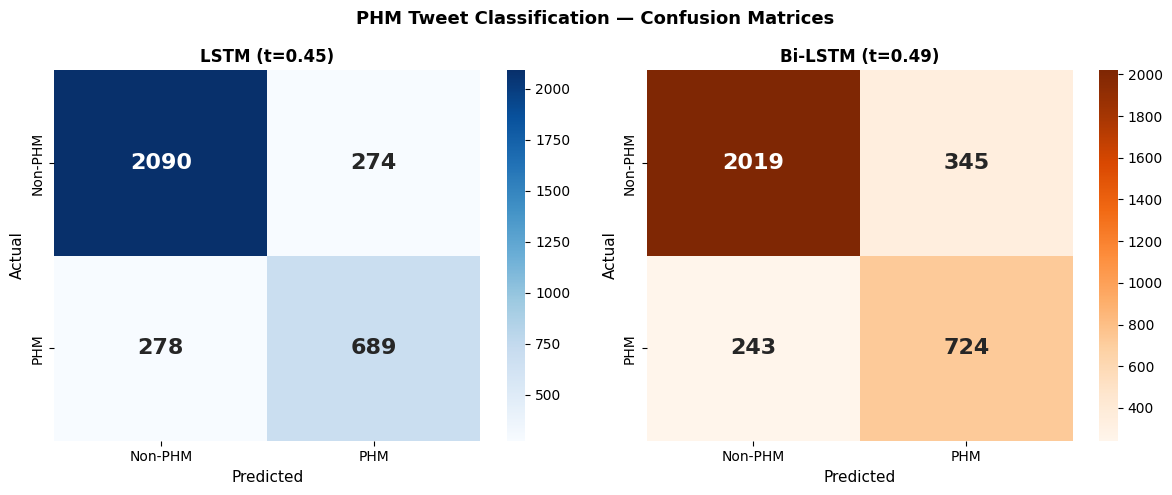

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('PHM Tweet Classification — Confusion Matrices', fontsize=13, fontweight='bold')
for ax, res, cmap in zip(axes, [lstm_res, bilstm_res], ['Blues', 'Oranges']):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Non-PHM', 'PHM'],
                yticklabels=['Non-PHM', 'PHM'],
                annot_kws={'size': 16, 'weight': 'bold'})
    ax.set_title(f"{res['name']} (t={res['threshold']:.2f})", fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. ROC & Precision-Recall Curves

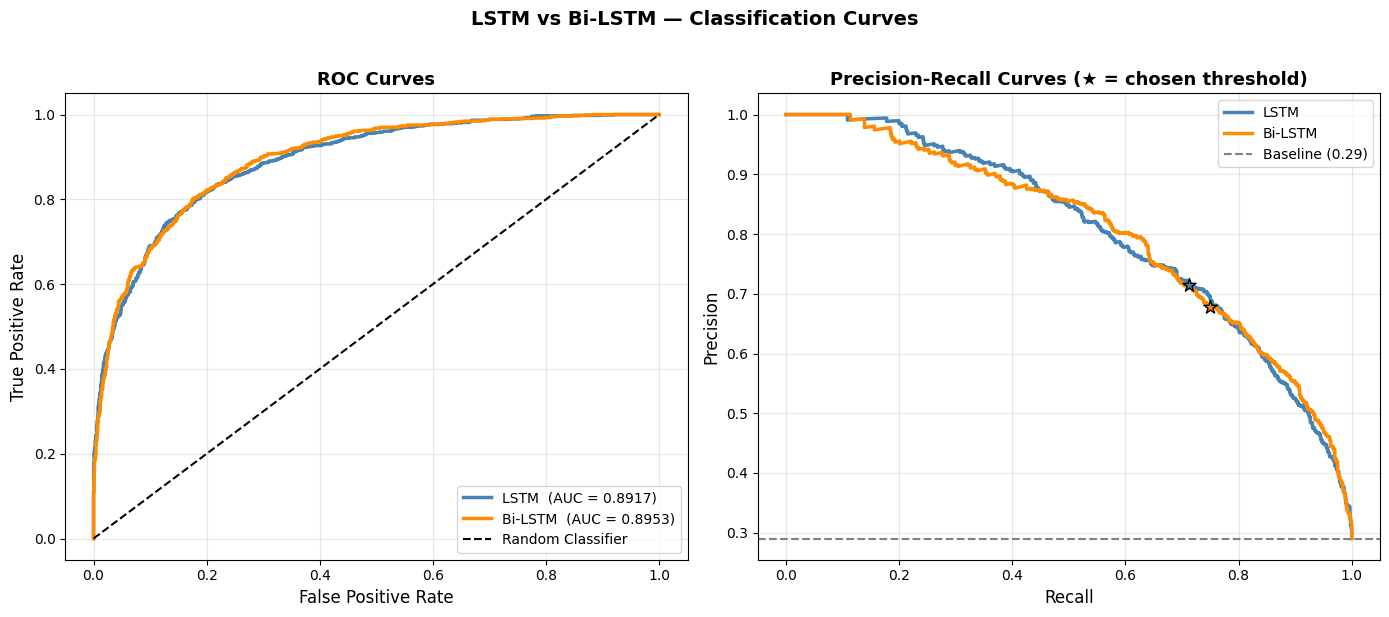

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
ax = axes[0]
for res, color in zip([lstm_res, bilstm_res], ['steelblue', 'darkorange']):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f"{res['name']}  (AUC = {res['auc']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Precision-Recall Curve
ax = axes[1]
for res, color in zip([lstm_res, bilstm_res], ['steelblue', 'darkorange']):
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, res['y_prob'])
    ax.plot(rec_vals, prec_vals, color=color, lw=2.5, label=f"{res['name']}")
    ax.scatter(res['recall'], res['precision'], color=color, s=100, zorder=5,
               edgecolors='black', marker='*')
baseline = y_test.mean()
ax.axhline(baseline, color='gray', ls='--', lw=1.5, label=f'Baseline ({baseline:.2f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves (★ = chosen threshold)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.suptitle('LSTM vs Bi-LSTM — Classification Curves', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Side-by-Side Training Curves Comparison

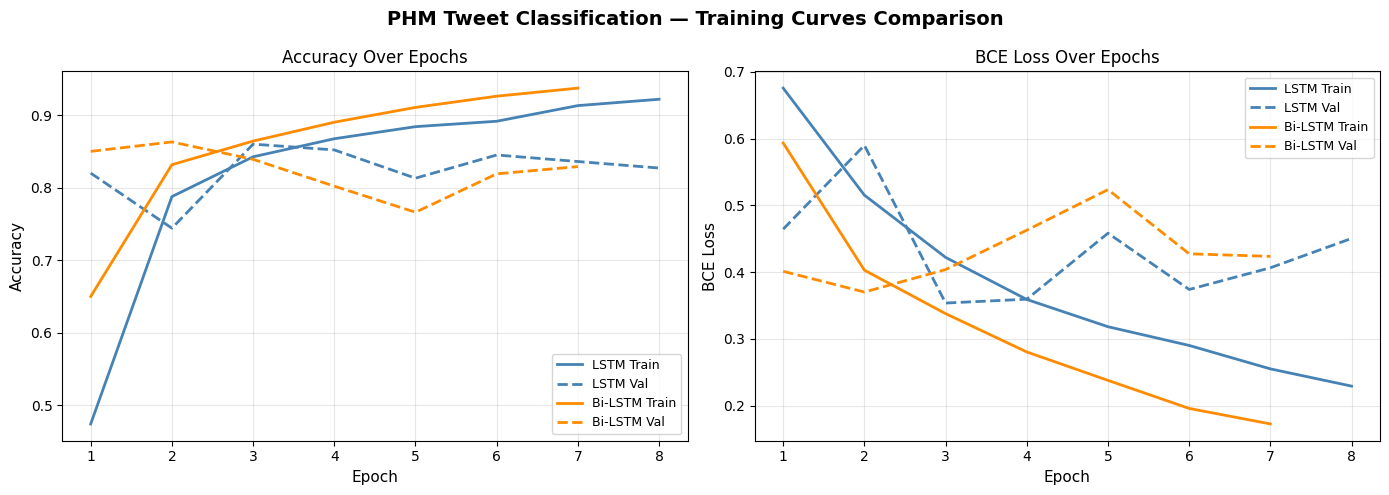

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PHM Tweet Classification — Training Curves Comparison', fontsize=14, fontweight='bold')
for ax, metric, ylabel in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'BCE Loss']):
    for hist, name, color in zip(
            [lstm_history, bilstm_history],
            ['LSTM', 'Bi-LSTM'],
            ['steelblue', 'darkorange']):
        ep = range(1, len(hist.history[metric]) + 1)
        ax.plot(ep, hist.history[metric],          color=color, lw=2,       label=f'{name} Train')
        ax.plot(ep, hist.history[f'val_{metric}'], color=color, lw=2, ls='--', label=f'{name} Val')
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'{ylabel} Over Epochs', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. K-Fold Cross-Validation

5-fold stratified CV for **robust metric estimates** with standard deviations.

In [20]:
# ── 5-Fold Stratified Cross-Validation ─────────────────────────────────────────
N_FOLDS = 5
CV_EPOCHS = 15
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

cv_results = {'LSTM': [], 'Bi-LSTM': []}

print(f'Running {N_FOLDS}-fold cross-validation...')
print('=' * 55)

for fold, (train_idx, val_idx) in enumerate(skf.split(x_train_pad, y_train), 1):
    print(f'\n--- Fold {fold}/{N_FOLDS} ---')
    X_tr, X_va = x_train_pad[train_idx], x_train_pad[val_idx]
    y_tr, y_va = y_train[train_idx], y_train[val_idx]

    w = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    cw = dict(zip(np.unique(y_tr).tolist(), w.tolist()))

    fold_callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=0, min_lr=1e-6)
    ]

    for name, builder in [('LSTM', build_lstm), ('Bi-LSTM', build_bilstm)]:
        m = builder()
        m.fit(X_tr, y_tr, epochs=CV_EPOCHS, batch_size=BATCH_SIZE,
              validation_data=(X_va, y_va), class_weight=cw,
              callbacks=fold_callbacks, verbose=0)

        y_prob = m.predict(X_va, verbose=0).flatten()
        y_pred = (y_prob >= 0.5).astype(int)
        cv_results[name].append({
            'accuracy': accuracy_score(y_va, y_pred),
            'f1_macro': f1_score(y_va, y_pred, average='macro'),
            'f1_weighted': f1_score(y_va, y_pred, average='weighted'),
            'auc': roc_auc_score(y_va, y_prob)
        })
        print(f'  {name:8s}  Acc={cv_results[name][-1]["accuracy"]:.4f}  '
              f'F1m={cv_results[name][-1]["f1_macro"]:.4f}  '
              f'AUC={cv_results[name][-1]["auc"]:.4f}')

    del m
    tf.keras.backend.clear_session()

print('\n' + '=' * 55)
print('  CROSS-VALIDATION SUMMARY (mean ± std)')
print('=' * 55)
for name in ['LSTM', 'Bi-LSTM']:
    df_cv = pd.DataFrame(cv_results[name])
    print(f'\n{name}:')
    for col in df_cv.columns:
        print(f'  {col:15s}: {df_cv[col].mean():.4f} ± {df_cv[col].std():.4f}')

Running 5-fold cross-validation...

--- Fold 1/5 ---
  LSTM      Acc=0.8024  F1m=0.7742  AUC=0.8737
  Bi-LSTM   Acc=0.8104  F1m=0.7832  AUC=0.8763

--- Fold 2/5 ---
  LSTM      Acc=0.8013  F1m=0.7743  AUC=0.8724
  Bi-LSTM   Acc=0.8023  F1m=0.7796  AUC=0.8861

--- Fold 3/5 ---
  LSTM      Acc=0.8178  F1m=0.7899  AUC=0.8869
  Bi-LSTM   Acc=0.8208  F1m=0.7905  AUC=0.8865

--- Fold 4/5 ---
  LSTM      Acc=0.8178  F1m=0.7759  AUC=0.8706
  Bi-LSTM   Acc=0.8153  F1m=0.7857  AUC=0.8814

--- Fold 5/5 ---
  LSTM      Acc=0.7993  F1m=0.7720  AUC=0.8702
  Bi-LSTM   Acc=0.8023  F1m=0.7751  AUC=0.8770

  CROSS-VALIDATION SUMMARY (mean ± std)

LSTM:
  accuracy       : 0.8077 ± 0.0093
  f1_macro       : 0.7773 ± 0.0072
  f1_weighted    : 0.8117 ± 0.0073
  auc            : 0.8748 ± 0.0069

Bi-LSTM:
  accuracy       : 0.8102 ± 0.0081
  f1_macro       : 0.7828 ± 0.0059
  f1_weighted    : 0.8151 ± 0.0067
  auc            : 0.8815 ± 0.0048


## 14. Performance Comparison Table & Bar Chart

In [22]:
# ── Summary table ──────────────────────────────────────────────────────────────
metrics     = ['Accuracy', 'Precision', 'Recall', 'Weighted F1', 'Macro F1', 'ROC-AUC']
lstm_vals   = [lstm_res['accuracy'],   lstm_res['precision'],   lstm_res['recall'],
               lstm_res['f1_w'],       lstm_res['f1_mac'],      lstm_res['auc']]
bilstm_vals = [bilstm_res['accuracy'], bilstm_res['precision'], bilstm_res['recall'],
               bilstm_res['f1_w'],     bilstm_res['f1_mac'],    bilstm_res['auc']]

comparison_df = pd.DataFrame({
    'Metric'  : metrics,
    f'LSTM (t={lstm_res["threshold"]:.2f})'    : [f'{v:.4f}' for v in lstm_vals],
    f'Bi-LSTM (t={bilstm_res["threshold"]:.2f})' : [f'{v:.4f}' for v in bilstm_vals]
}).set_index('Metric')

print('\n' + '=' * 60)
print('  PERFORMANCE COMPARISON TABLE')
print('=' * 60)
print(comparison_df.to_string())
print('=' * 60)


  PERFORMANCE COMPARISON TABLE
            LSTM (t=0.45) Bi-LSTM (t=0.49)
Metric                                    
Accuracy           0.8343           0.8235
Precision          0.7155           0.6773
Recall             0.7125           0.7487
Weighted F1        0.8342           0.8260
Macro F1           0.7987           0.7920
ROC-AUC            0.8917           0.8953


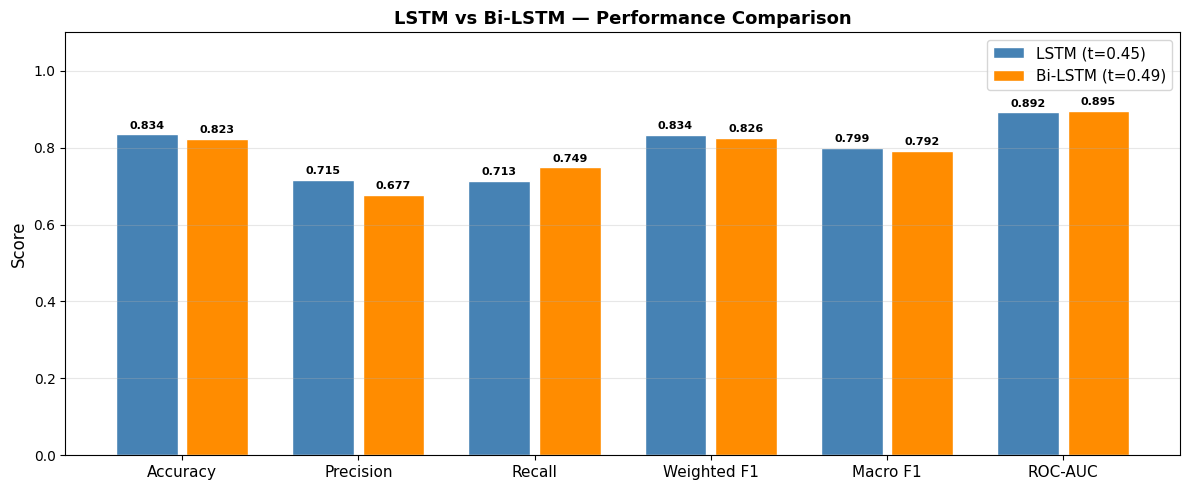

In [23]:
# ── Bar chart comparison ───────────────────────────────────────────────────────
x = np.arange(len(metrics))
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - 0.2, [float(v) for v in lstm_vals],   0.35,
            label=f'LSTM (t={lstm_res["threshold"]:.2f})',    color='steelblue',  edgecolor='white')
b2 = ax.bar(x + 0.2, [float(v) for v in bilstm_vals], 0.35,
            label=f'Bi-LSTM (t={bilstm_res["threshold"]:.2f})', color='darkorange', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title('LSTM vs Bi-LSTM — Performance Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()